##### STARTUCTURE FORMAT
↓
Dataset Overview
↓
ETL Process
↓
Data Preprocessing
↓
EDA
↓
Feature Selection
↓
Train-Test Split
↓
Linear Regression Model
↓
Model Evaluation
↓
Actual vs Predicted Values
↓
Conclusion

# House Price Prediction Using Machine Learning

## Introduction

The real estate industry plays an important role in economic growth and investment decisions. House prices are influenced by several factors such as property size, number of bedrooms, number of bathrooms, location quality, lot size, and other structural characteristics. Accurately estimating house prices is valuable for buyers, sellers, investors, and real estate agencies.

As the housing market continues to evolve, understanding the factors that affect property prices has become increasingly important. Traditional pricing methods often rely on manual assessments, which may not always provide accurate and consistent results. Data-driven approaches can help identify key factors influencing house prices and improve prediction accuracy.

This project focuses on analyzing residential property data and developing a machine learning model to predict house prices. The dataset contains information about property characteristics such as Square Footage, Number of Bedrooms, Number of Bathrooms, Year Built, Lot Size, Garage Size, Neighborhood Quality, and House Price.

Exploratory Data Analysis (EDA) is performed to understand the dataset, identify patterns, and examine relationships between features and house prices. Machine learning techniques are then applied to build a predictive model that can estimate house prices based on property attributes.

The findings of this project can help support data-driven decision-making in the real estate sector and provide insights into the factors that have the greatest impact on property values.


## What is House Price Regression Data?

The House Price Regression dataset contains information about residential properties and the factors that influence house prices. The dataset is designed to help analyze property characteristics and develop machine learning models for house price prediction.

Each row in the dataset represents a single residential property along with its structural and neighborhood-related attributes.

Key variables tracked in the dataset include:

* Square_Footage — Total area of the house in square feet
* Num_Bedrooms — Number of bedrooms in the house
* Num_Bathrooms — Number of bathrooms in the house
* Year_Built — Year in which the house was constructed
* Lot_Size — Size of the land associated with the property
* Garage_Size — Number of vehicles that can be accommodated in the garage
* Neighborhood_Quality — Quality rating of the neighborhood
* House_Price — Market price of the house (Target Variable)


## Importing Libraries

In [1]:
import pandas as pd
import numpy as np # Data Handling
import matplotlib.pyplot as plt
import seaborn as sns # Data Visualization
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression # Machine Learning
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Model Evaluation

df=pd.read_csv(r"C:\datascience\ml_project\house_price_regression_dataset.csv")
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## Dataset Overview

| Column Name | Description |
|------------|-------------|
| Square_Footage | Total area of the house in square feet |
| Num_Bedrooms | Number of bedrooms in the house |
| Num_Bathrooms | Number of bathrooms in the house |
| Year_Built | Year in which the house was constructed |
| Lot_Size | Size of the land associated with the property |
| Garage_Size | Number of vehicles that can be accommodated in the garage |
| Neighborhood_Quality | Quality rating of the neighborhood |
| House_Price | Market price of the house (Target Variable) |

## Extract Transform Load (ETL) Process

### Data Extraction
The House Price Regression dataset was collected from a CSV file and imported into Python using the Pandas library for analysis and machine learning.

### Data Transformation
The dataset was examined to understand its structure, data types, and statistical properties. Data quality checks were performed to identify missing values and duplicate records. Since the dataset was clean and contained only numerical features, no major transformations were required.

### Data Loading
The prepared dataset was loaded into a Pandas DataFrame and made ready for exploratory data analysis, feature selection, and machine learning model development.

## Data Preprocessing

### Missing Values Analysis

In [2]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

### Observation

No missing values were found in the dataset. Since all columns contain complete information, the dataset is clean and ready for further preprocessing, exploratory data analysis, and machine learning model development.

### Duplicate Values Analysis

In [3]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate records were found in the dataset. Each row represents a unique property, ensuring that the data is reliable and suitable for exploratory analysis and machine learning model development.

### Unknown Symbols Check

In [4]:
df.isin(['?', 'NA', 'N/A', '-', '*']).sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

### Observation

No unknown symbols or invalid entries were detected in the dataset. All feature values are valid and suitable for further analysis and machine learning model development.

### Data Types Analysis

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Observation

The dataset contains 1000 records and 8 columns. All columns have complete data with no missing values. The dataset consists of 6 integer-type features and 2 float-type features. Since all variables are numerical and correctly assigned to their respective data types, no data type conversion was required before analysis and machine learning model development.

## Statistical Summary

In [6]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


### Observation

The statistical summary shows that the dataset contains 1000 property records with a wide range of house characteristics. The average house price is approximately $618,861, while the median house price is approximately $628,267. Features such as square footage, bedrooms, bathrooms, and neighborhood quality show sufficient variation, making the dataset suitable for exploratory analysis and machine learning model development.
Mean (Average Price) = $618,861
Median Price = $628,267

## Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) was performed to understand the distribution of features, identify patterns, and examine relationships between independent variables and the target variable (House_Price). Various visualizations were used to gain insights into the dataset before building machine learning models.

### 1. House Price Distribution

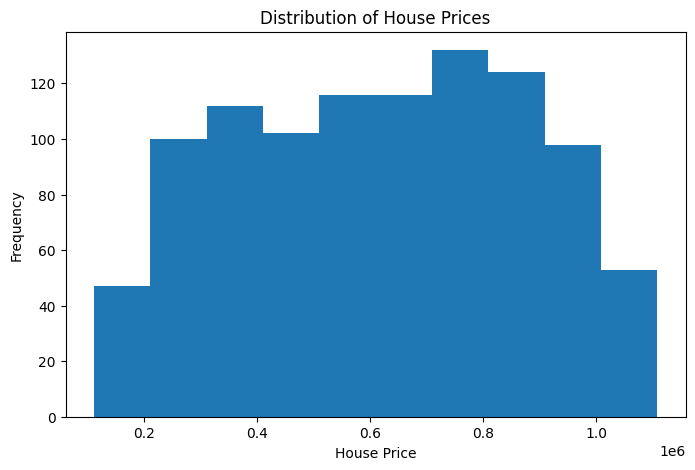

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['House_Price'], bins=10)
plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.show()

The histogram shows the distribution of house prices in the dataset. Most properties are concentrated in the middle price range, while fewer houses are found at very low and very high price levels.

### 2. Average House Price by Number of Bedrooms

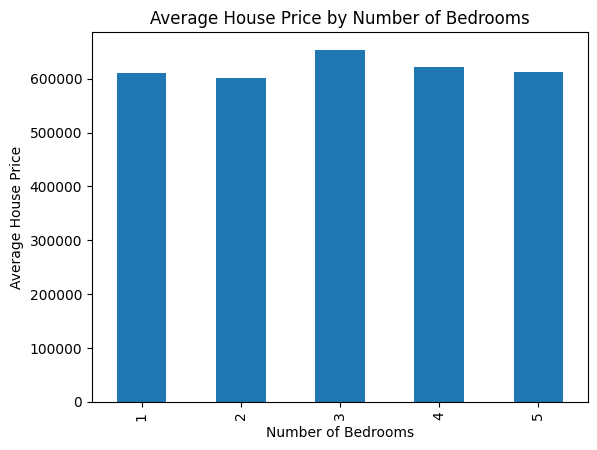

In [8]:
df.groupby('Num_Bedrooms')['House_Price'].mean().plot(kind='bar')

plt.title('Average House Price by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average House Price')
plt.show()

The bar chart shows the average house price for different numbers of bedrooms. Houses with more bedrooms generally tend to have higher average prices compared to houses with fewer bedrooms.

### 3. Average House Price by Number of Bathrooms

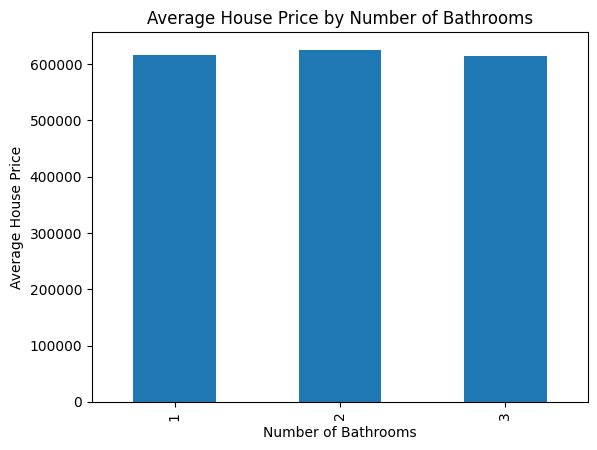

In [9]:
df.groupby('Num_Bathrooms')['House_Price'].mean().plot(kind='bar')

plt.title('Average House Price by Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Average House Price')
plt.show()

The average house price increases as the number of bathrooms increases. This suggests that properties with more bathrooms are generally more valuable.

### 4. Average House Price by Neighborhood Quality

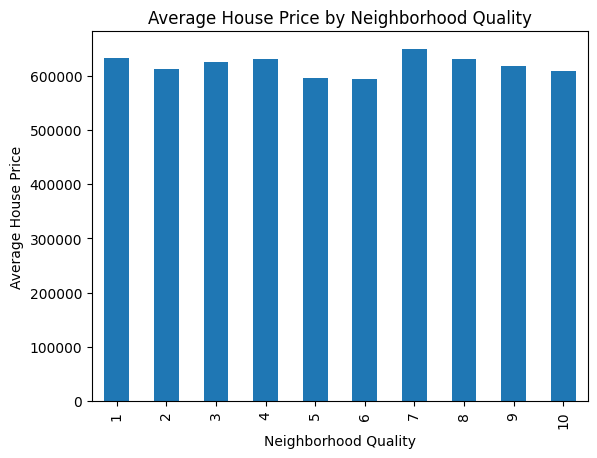

In [10]:
df.groupby('Neighborhood_Quality')['House_Price'].mean().plot(kind='bar')

plt.title('Average House Price by Neighborhood Quality')
plt.xlabel('Neighborhood Quality')
plt.ylabel('Average House Price')
plt.show()

The chart indicates that houses located in higher-quality neighborhoods tend to have higher average prices. Neighborhood quality appears to be an important factor affecting house value.

### 5. Correlation Heatmap

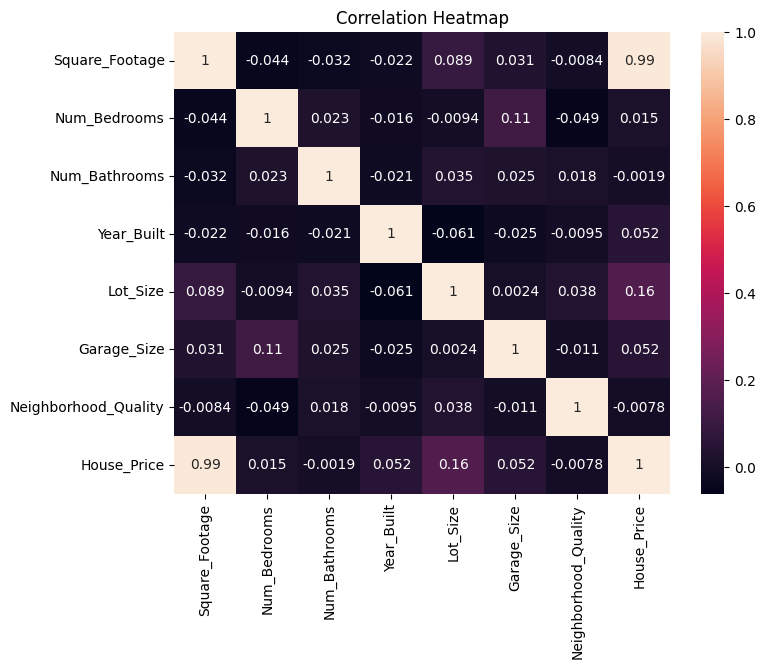

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)

plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows the relationships between features and house prices. Features with higher positive correlation values have a stronger influence on house prices and may be important predictors in the machine learning model.

# Feature Selection

In [12]:
X = df.drop('House_Price', axis=1)
y = df['House_Price']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 7)
Target Shape: (1000,)


### Observation

The dataset was divided into independent variables (features) and the target variable (House_Price). A total of 7 features were selected for model training, while House_Price was chosen as the variable to be predicted.

# Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 7)
X_test : (200, 7)
y_train: (800,)
y_test : (200,)


### Observation

The dataset was split into training and testing sets using an 80:20 ratio. The training data will be used to build the machine learning model, while the testing data will be used to evaluate its predictive performance.

# Model Building - Linear Regression

In [14]:
from sklearn.linear_model import LinearRegression #-import linear regression
model = LinearRegression() #train the model
model.fit(X_train, y_train)
y_pred = model.predict(X_test) #make predictions

### Observation

The Linear Regression model was trained using the training dataset and used to predict house prices for the testing dataset. The predicted values will be compared with actual house prices to evaluate the model's performance.

# Model Evaluation

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred) #CALCULATE METRICS

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE : 8174.583600008741
MSE : 101434798.50566845
RMSE: 10071.4844241387
R² Score: 0.9984263636823408


### Observation

The Linear Regression model was evaluated using MAE, MSE, RMSE, and R² Score. These metrics measure the prediction error and the model's ability to explain variations in house prices. A higher R² score and lower error values indicate better model performance.

### Actual vs Predicted Values

In [16]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
521,9.010005e+05,8.686871e+05
737,4.945375e+05,4.903379e+05
740,9.494042e+05,9.456671e+05
660,1.040389e+06,1.033403e+06
411,7.940100e+05,7.766988e+05
678,7.240336e+05,7.324441e+05
626,9.984392e+05,9.950520e+05
513,9.097134e+05,8.851748e+05
859,7.926815e+05,7.967305e+05
136,9.474908e+05,9.317411e+05


### Observation

The predicted house prices are very close to the actual house prices, indicating that the Linear Regression model has successfully learned the relationship between the property features and the target variable. The results suggest that the model is capable of making accurate house price predictions on unseen data.

## evaluation metrics

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 8174.583600008741
MSE: 101434798.50566845
RMSE: 10071.4844241387
R2 Score: 0.9984263636823408


### Observation

The Linear Regression model achieved a Mean Absolute Error (MAE) of 8,174.58 and a Root Mean Squared Error (RMSE) of 10,071.48, indicating that the prediction errors are relatively small compared to the overall house prices. The model achieved an R² Score of 0.9984, meaning that approximately 99.84% of the variation in house prices is explained by the selected features. These results demonstrate that the model performs exceptionally well and provides highly accurate house price predictions.

# Conclusion

This project successfully developed a House Price Prediction model using Linear Regression. The dataset was explored through Exploratory Data Analysis (EDA), cleaned through preprocessing techniques, and prepared for machine learning model development.

Various property-related features such as square footage, number of bedrooms, number of bathrooms, lot size, garage size, year built, and neighborhood quality were used to predict house prices. The Linear Regression model demonstrated excellent performance, achieving an R² Score of 0.9984, indicating a very strong relationship between the selected features and house prices.

The results show that the model can accurately estimate house prices and can be used as a reliable tool for property value prediction. Overall, the project highlights the effectiveness of machine learning techniques in solving real-world regression problems and supporting data-driven decision-making in the real estate industry.

# Model Building - Polynomial Regression

## Introduction

Polynomial Regression is an advanced form of Linear Regression used to model non-linear relationships between independent variables and the target variable. Instead of fitting a straight line, Polynomial Regression fits a curved relationship by transforming the original features into polynomial features. This helps improve prediction accuracy when the relationship between variables is more complex.

## Why Polynomial Regression?

Linear Regression assumes a linear relationship between the input features and the target variable. However, real-world datasets often contain non-linear patterns. Polynomial Regression helps capture these patterns and may provide better predictions compared to Linear Regression.

In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()

model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

The Polynomial Regression model was trained using polynomial features of degree 2. By creating additional feature combinations, the model can capture more complex relationships between house characteristics and house prices.

## Actual vs Predicted Values - Polynomial Regression

In [19]:
comparison_poly = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred_poly
})

comparison_poly.head(10)

,Actual Price,Predicted Price
521,9.010005e+05,8.700475e+05
737,4.945375e+05,4.903768e+05
740,9.494042e+05,9.467490e+05
660,1.040389e+06,1.034178e+06
411,7.940100e+05,7.743000e+05
678,7.240336e+05,7.305061e+05
626,9.984392e+05,9.939835e+05
513,9.097134e+05,8.817542e+05
859,7.926815e+05,7.947135e+05
136,9.474908e+05,9.325557e+05


The predicted values are compared with the actual house prices. Most predicted values are close to the actual values, indicating that the model performs well on unseen data.

## Model Evaluation - Polynomial Regression

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 8311.015874644976
MSE : 103781419.49867618
RMSE: 10187.316599511187
R² Score: 0.9983899587397296


The performance of the Polynomial Regression model was measured using MAE, MSE, RMSE, and R² Score. These metrics help evaluate prediction accuracy and determine how well the model fits the data.

## Model Evaluation - Polynomial Regression

### Results

- MAE : 8311.02
- MSE : 103781419.50
- RMSE : 10187.32
- R² Score : 0.9984

The Polynomial Regression model achieved a very low prediction error and an R² Score of 0.9984. This indicates that the model explains approximately 99.84% of the variation in house prices and provides highly accurate predictions.

## Model Comparison

| Metric | Linear Regression | Polynomial Regression |
|----------|----------:|----------:|
| MAE | 8174.58 | 8311.02 |
| MSE | 101434798.51 | 103781419.50 |
| RMSE | 10071.48 | 10187.32 |
| R² Score | 0.9984 | 0.9984 |

The performance of Linear Regression and Polynomial Regression models was compared using evaluation metrics. Both models achieved excellent prediction accuracy with R² Scores above 99%.

However, Linear Regression produced slightly lower error values and a marginally higher R² Score than Polynomial Regression. Therefore, Linear Regression was found to be the better-performing model for this dataset.

# Conclusion

In this project, House Price Prediction was performed using both Linear Regression and Polynomial Regression techniques. Data preprocessing, exploratory data analysis, feature selection, model training, and evaluation were successfully completed.

The results showed that both models performed exceptionally well in predicting house prices. Both achieved very high accuracy with R² Scores above 99%.

However, Linear Regression achieved slightly lower prediction errors and a marginally higher R² Score compared to Polynomial Regression. Therefore, Linear Regression was found to be the best-performing model for this dataset.

This project demonstrates how machine learning techniques can be used to estimate house prices and support data-driven decision-making in the real estate industry.

1. Introduction

2. What is House Price Data?

3. Import Libraries

4. Load Dataset

5. Dataset Overview

6. ETL Process

7. Data Preprocessing
   - Missing Values Check
   - Duplicate Values Check
   - Unknown Symbols Check
   - Statistical Summary

8. Exploratory Data Analysis (EDA)
   - House Price Distribution
   - Average House Price by Number of Bedrooms
   - Average House Price by Number of Bathrooms
   - Average House Price by Neighborhood Quality
   - Correlation Heatmap

9. Feature Selection

10. Train-Test Split

11. Model Building - Linear Regression

12. Actual vs Predicted Values - Linear Regression

13. Model Evaluation - Linear Regression

14. Model Building - Polynomial Regression

15. Actual vs Predicted Values - Polynomial Regression

16. Model Evaluation - Polynomial Regression

17. Model Comparison

18. Conclusion
```

### Final Results

| Model                 | R² Score |
| --------------------- | -------: |
| Linear Regression     |   0.9984 |
| Polynomial Regression |   0.9984 |

🏆 **Best Model: Linear Regression**